In [6]:
!pip install torch torchvision torchaudio
!pip install transformers
!pip install protobuf

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Affan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Affan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Affan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import os
import torch
import librosa
import numpy as np
import warnings
from transformers import Wav2Vec2Processor, Wav2Vec2Model

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading Wav2Vec2 Model from HuggingFace...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

emotion_map = {"W": 0, "L": 1, "E": 2, "A": 3, "F": 4, "T": 5, "N": 6}

def extract_mfcc(audio_path):
    waveform, sr = librosa.load(audio_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=waveform, sr=16000, n_mfcc=13)
    return np.mean(mfcc, axis=1)

def extract_wav2vec(audio_path):
    waveform, _ = librosa.load(audio_path, sr=16000)
    inputs = processor(waveform, sampling_rate=16000, return_tensors="pt", padding=True)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        
    wav2vec_features = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return wav2vec_features

def extract_combined_features(audio_path):
    mfcc_feat = extract_mfcc(audio_path)
    wav2vec_feat = extract_wav2vec(audio_path)
    
    mfcc_feat = (mfcc_feat - np.mean(mfcc_feat)) / (np.std(mfcc_feat) + 1e-6)
    wav2vec_feat = (wav2vec_feat - np.mean(wav2vec_feat)) / (np.std(wav2vec_feat) + 1e-6)
    
    return np.concatenate((mfcc_feat, wav2vec_feat), axis=0)

pipelines = [
    {"input_dir": r"E:\SSP-Project-V1\wav", "output_dir": "Extracted_Features_Clean"},
    {"input_dir": "Noisy_EmoDB", "output_dir": "Extracted_Features_Noisy"},
    {"input_dir": "Enhanced_EmoDB_PAPER", "output_dir": "Extracted_Features_PAPER"},
    {"input_dir": "Enhanced_EmoDB_MMSE", "output_dir": "Extracted_Features_MMSE"}
]

for pipeline in pipelines:
    input_base_dir = pipeline["input_dir"]
    output_features_dir = pipeline["output_dir"]
    
    if not os.path.exists(input_base_dir):
        continue
        
    print(f"Starting extraction pipeline: {input_base_dir}")
    os.makedirs(output_features_dir, exist_ok=True)
    
    base_files = [f for f in os.listdir(input_base_dir) if f.endswith('.wav')]
    if base_files:
        print("Extracting features for Clean Base Directory")
        X_combined = []
        Y = []
        
        for filename in base_files:
            emotion_char = filename[5]  
            label = emotion_map.get(emotion_char, -1)
            
            if label == -1: 
                continue 
                
            file_path = os.path.join(input_base_dir, filename)
            combined_feat = extract_combined_features(file_path)
            
            X_combined.append(combined_feat)
            Y.append(label)

        X_array = np.array(X_combined)
        Y_array = np.array(Y)
        
        np.save(os.path.join(output_features_dir, "X_Clean.npy"), X_array)
        np.save(os.path.join(output_features_dir, "Y_Clean.npy"), Y_array)
        print(f"Saved: X_Clean.npy (Shape: {X_array.shape})")

    subfolders = [f for f in os.listdir(input_base_dir) if os.path.isdir(os.path.join(input_base_dir, f))]

    for folder_name in subfolders:
        print(f"Extracting features for {folder_name}")
        
        folder_path = os.path.join(input_base_dir, folder_name)
        audio_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
        
        X_combined = []
        Y = []
        
        for filename in audio_files:
            emotion_char = filename[5]  
            label = emotion_map.get(emotion_char, -1)
            
            if label == -1: 
                continue 
                
            file_path = os.path.join(folder_path, filename)
            combined_feat = extract_combined_features(file_path)
            
            X_combined.append(combined_feat)
            Y.append(label)

        X_array = np.array(X_combined)
        Y_array = np.array(Y)
        
        np.save(os.path.join(output_features_dir, f"X_{folder_name}.npy"), X_array)
        np.save(os.path.join(output_features_dir, f"Y_{folder_name}.npy"), Y_array)
        
        print(f"Saved: X_{folder_name}.npy (Shape: {X_array.shape})")

print("All pipelines complete.")

C:\Users\Affan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Loading Wav2Vec2 Model from HuggingFace...


Loading weights: 100%|██████████| 210/210 [00:00<00:00, 2114.97it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting extraction pipeline: E:\SSP-Project-V1\wav
Extracting features for Clean Base Directory
Saved: X_Clean.npy (Shape: (535, 781))
Starting extraction pipeline: Noisy_EmoDB
Extracting features for Cafe_-10dB
Saved: X_Cafe_-10dB.npy (Shape: (535, 781))
Extracting features for Cafe_-5dB
Saved: X_Cafe_-5dB.npy (Shape: (535, 781))
Extracting features for Cafe_0dB
Saved: X_Cafe_0dB.npy (Shape: (535, 781))
Extracting features for Cafe_10dB
Saved: X_Cafe_10dB.npy (Shape: (535, 781))
Extracting features for Cafe_15dB
Saved: X_Cafe_15dB.npy (Shape: (535, 781))
Extracting features for Cafe_5dB
Saved: X_Cafe_5dB.npy (Shape: (535, 781))
Extracting features for Street_-10dB
Saved: X_Street_-10dB.npy (Shape: (535, 781))
Extracting features for Street_-5dB
Saved: X_Street_-5dB.npy (Shape: (535, 781))
Extracting features for Street_0dB
Saved: X_Street_0dB.npy (Shape: (535, 781))
Extracting features for Street_10dB
Saved: X_Street_10dB.npy (Shape: (535, 781))
Extracting features for Street_15dB
Sa

Generating Feature Anatomy Dashboard for White Noise...


Loading weights: 100%|██████████| 210/210 [00:00<00:00, 1820.52it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


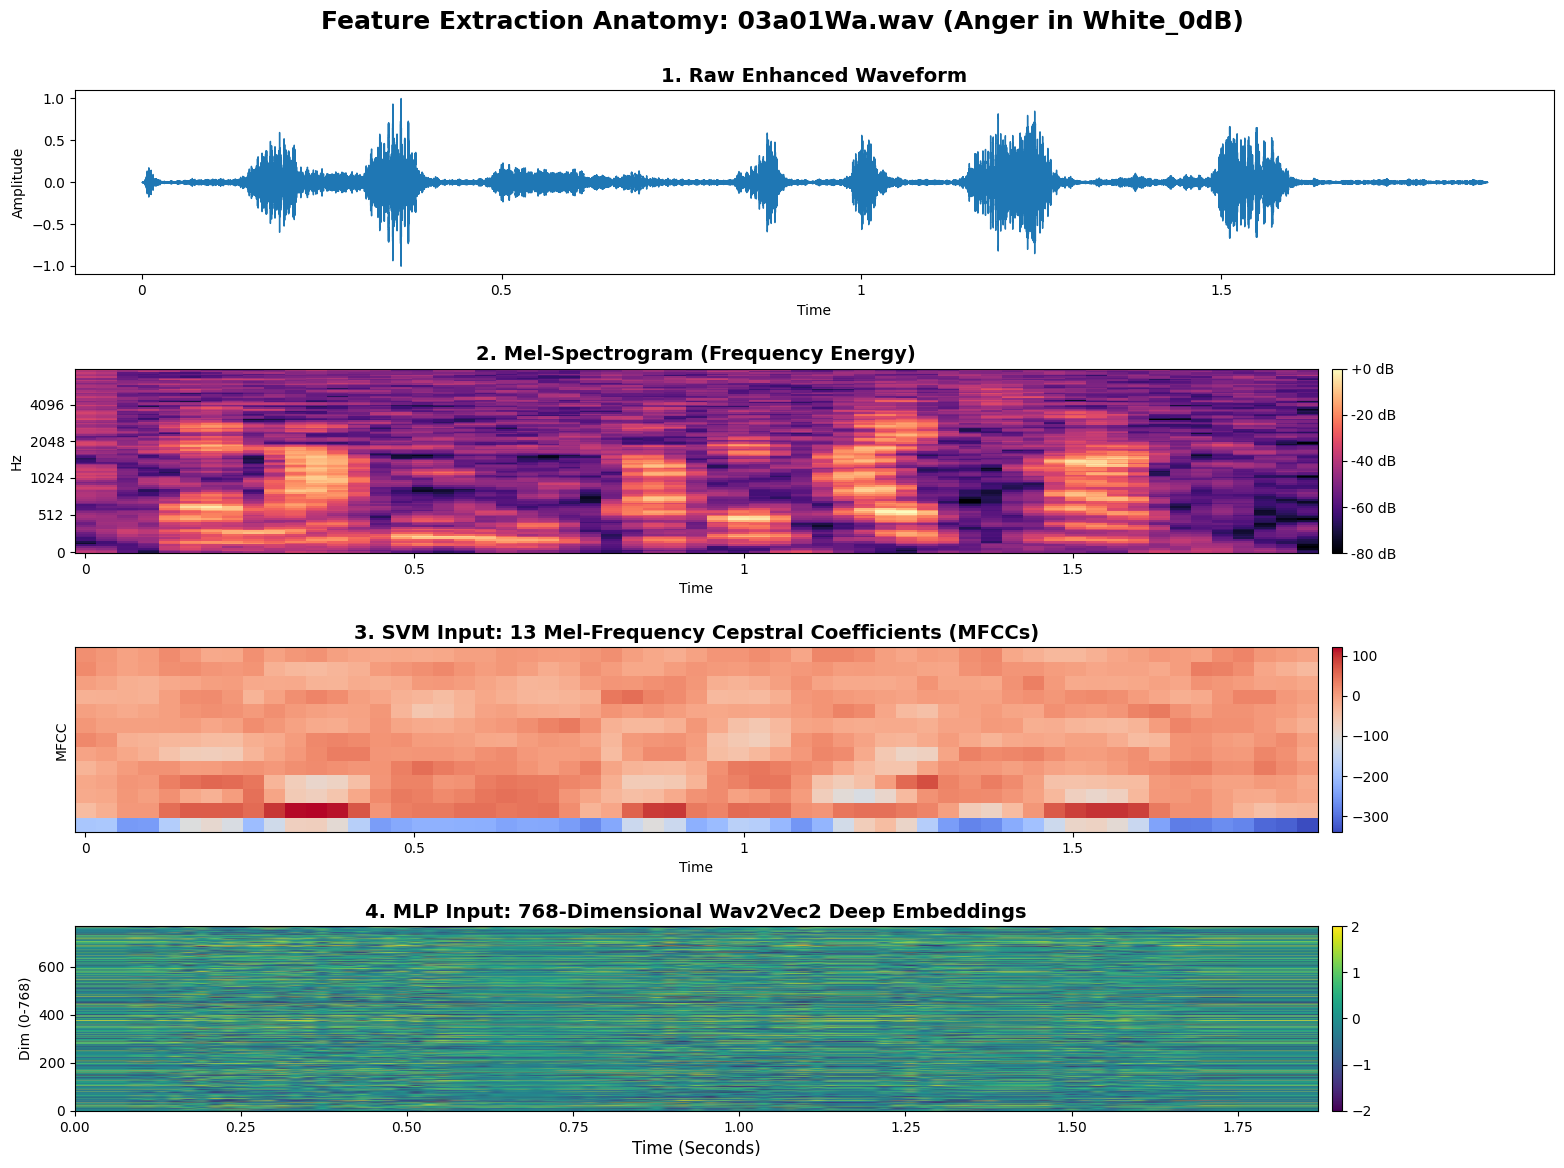

Feature Anatomy dashboard saved to: images\Visualization_3_Feature_Anatomy_White.png


In [1]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')
from transformers import Wav2Vec2Processor, Wav2Vec2Model

print("Generating Feature Anatomy Dashboard for White Noise...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

enhanced_dir = "Enhanced_EmoDB_MMSE"
env = "White_0dB"
img_dir = "images"
os.makedirs(img_dir, exist_ok=True)

target_folder = os.path.join(enhanced_dir, env)
all_files = [f for f in os.listdir(target_folder) if f.endswith('.wav')]
anger_files = [f for f in all_files if len(f) > 5 and f[5] == 'W']

if not anger_files:
    print("Error: Could not find an Anger file.")
else:
    sample_file = anger_files[0]
    file_path = os.path.join(target_folder, sample_file)
    
    y, sr = librosa.load(file_path, sr=16000)
    
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    inputs = processor(y, sampling_rate=16000, return_tensors="pt", padding=True)
    inputs = {key: val.to(device) for key, val in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    w2v_features = outputs.last_hidden_state.squeeze().cpu().numpy().T 
    
    w2v_features_norm = (w2v_features - np.mean(w2v_features)) / (np.std(w2v_features) + 1e-6)
    
    fig = plt.figure(figsize=(16, 12))
    plt.suptitle(f"Feature Extraction Anatomy: {sample_file} (Anger in {env})", fontsize=18, fontweight='bold', y=0.98)
    
    plt.subplot(4, 1, 1)
    librosa.display.waveshow(y, sr=sr, color='#1f77b4')
    plt.title(f"1. Raw Enhanced Waveform", fontsize=14, fontweight='bold')
    plt.ylabel("Amplitude")
    
    plt.subplot(4, 1, 2)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000, cmap='magma')
    plt.colorbar(format='%+2.0f dB', pad=0.01)
    plt.title("2. Mel-Spectrogram (Frequency Energy)", fontsize=14, fontweight='bold')
    plt.ylabel("Hz")
    
    plt.subplot(4, 1, 3)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time', cmap='coolwarm')
    plt.colorbar(pad=0.01)
    plt.title("3. SVM Input: 13 Mel-Frequency Cepstral Coefficients (MFCCs)", fontsize=14, fontweight='bold')
    plt.ylabel("MFCC")
    
    plt.subplot(4, 1, 4)
    plt.imshow(w2v_features_norm, aspect='auto', origin='lower', cmap='viridis', 
               vmin=-2, vmax=2, extent=[0, librosa.get_duration(y=y, sr=sr), 0, 768])
    plt.colorbar(pad=0.01)
    plt.title("4. MLP Input: 768-Dimensional Wav2Vec2 Deep Embeddings", fontsize=14, fontweight='bold')
    plt.ylabel("Dim (0-768)")
    plt.xlabel("Time (Seconds)", fontsize=12)
    
    plt.tight_layout(pad=2.0)
    save_path = os.path.join(img_dir, "Visualization_3_Feature_Anatomy_White.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Feature Anatomy dashboard saved to: {save_path}")